# Predictive Analytics: Stock Prediction, Sales Forecasting & Waiter Tips Regression

**Name: MD. Shafiqul Islam** &nbsp;&nbsp; **Student ID: 905253024** &nbsp;&nbsp; 

This notebook covers Deliverables 1 and 2, built on a self-generated synthetic dataset
(`synthetic_predictive_analytics_dataset.xlsx`) with the same structure as the course dataset:

- Part 1 — Stock price prediction with an LSTM (ticker: **NOVATECH**)
- Part 2 — Sales forecasting with Holt-Winters Exponential Smoothing (store: **Harborview**)
- Part 3 — Waiter tips regression, baseline through three refinements
- Part 4 — Saving and reloading a deployable prediction pipeline


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"

os.makedirs("../outputs", exist_ok=True)

xl = pd.ExcelFile("../data/synthetic_predictive_analytics_dataset.xlsx")
print(xl.sheet_names)

['Stock_Prices', 'Sales_Data', 'Waiter_Tips']


## Part 1 — Stock Price Prediction Using an LSTM

We take one ticker's closing prices, scale them to [0, 1], build sliding windows (past 20
trading days predicting the next day's close), and train a small LSTM. The train/test split
is **time-based**, not random — the model is trained only on earlier dates and evaluated only
on dates it has never seen.

(750, 7)


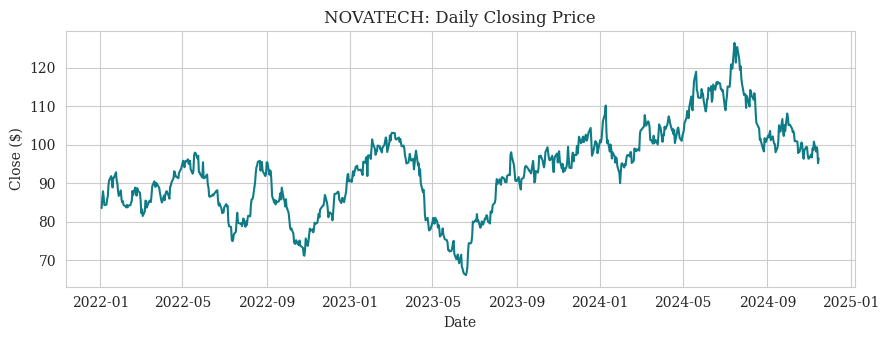

In [28]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

tf.random.set_seed(42)

stock = pd.read_excel("../data/synthetic_predictive_analytics_dataset.xlsx", sheet_name="Stock_Prices", parse_dates=["date"])
ticker_df = stock[stock["ticker"] == "NOVATECH"].sort_values("date").reset_index(drop=True)
print(ticker_df.shape)

plt.figure(figsize=(9, 3.5))
plt.plot(ticker_df["date"], ticker_df["close"], color="#0E7C86")
plt.title("NOVATECH: Daily Closing Price")
plt.xlabel("Date"); plt.ylabel("Close ($)")
plt.tight_layout()
plt.savefig("../outputs/stock_price_history.png", dpi=120)
plt.show()

In [29]:
prices = ticker_df["close"].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)

WINDOW = 20
X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i - WINDOW:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)  # [samples, timesteps, features]

# Time-based split: earliest ~80% for training, most recent ~20% held out for testing.
# We never shuffle a time series before splitting -- shuffling would let the model
# "see the future" (train on a date that comes after a date it's tested on), which
# would make the test score meaningless as an estimate of real forecasting performance.
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"train sequences: {len(X_train)}   test sequences: {len(X_test)}")

train sequences: 584   test sequences: 146


In [30]:
lstm_model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.LSTM(32, return_sequences=False),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

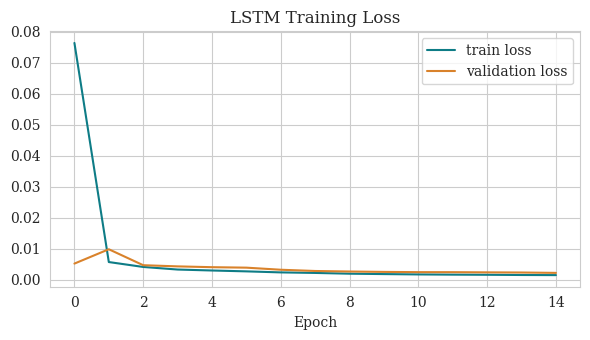

In [31]:
history = lstm_model.fit(X_train, y_train, epochs=15, batch_size=16,
                          validation_data=(X_test, y_test), verbose=0)

plt.figure(figsize=(6, 3.5))
plt.plot(history.history["loss"], label="train loss", color="#0E7C86")
plt.plot(history.history["val_loss"], label="validation loss", color="#D9822B")
plt.legend(); plt.title("LSTM Training Loss"); plt.xlabel("Epoch")
plt.tight_layout()
plt.savefig("../outputs/lstm_training_loss.png", dpi=120)
plt.show()

LSTM RMSE on held-out (later) test dates: $2.85


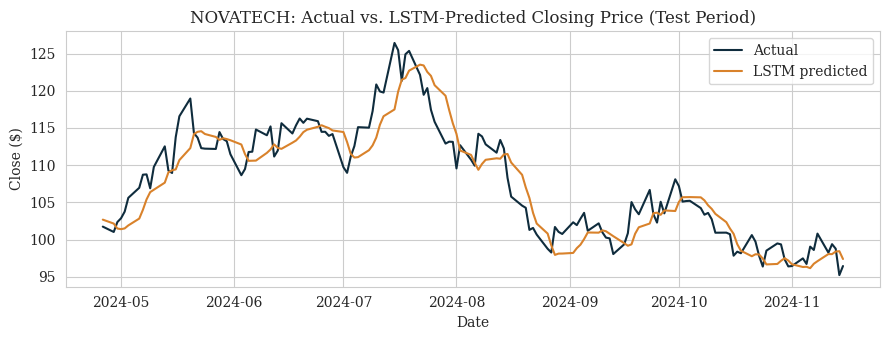

In [32]:
pred_scaled = lstm_model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

lstm_rmse = float(mean_squared_error(actual, pred) ** 0.5)
print(f"LSTM RMSE on held-out (later) test dates: ${lstm_rmse:.2f}")

test_dates = ticker_df["date"].values[WINDOW + split:]
plt.figure(figsize=(9, 3.5))
plt.plot(test_dates, actual, label="Actual", color="#0F2C3D")
plt.plot(test_dates, pred, label="LSTM predicted", color="#D9822B")
plt.title("NOVATECH: Actual vs. LSTM-Predicted Closing Price (Test Period)")
plt.xlabel("Date"); plt.ylabel("Close ($)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/lstm_actual_vs_predicted.png", dpi=120)
plt.show()

The LSTM follows the overall trend reasonably well, but it consistently lags at sharp turning points — most visibly around the July peak, where actual price hits about $126 while the prediction only reaches roughly 120 dollar and arrives a few days late. This makes sense given the model only sees past closing prices: it can extrapolate a trend already in motion, but it has no way to anticipate a reversal before the data itself starts showing one.

## Part 2 — Sales Forecasting with Holt-Winters Exponential Smoothing

We forecast daily sales for one store using classical time-series decomposition (trend +
weekly seasonality + residual) and Holt-Winters Exponential Smoothing, which explicitly
models both trend and seasonality. The split is again time-based: the most recent 60 days
are held out as the test period.

(730,)


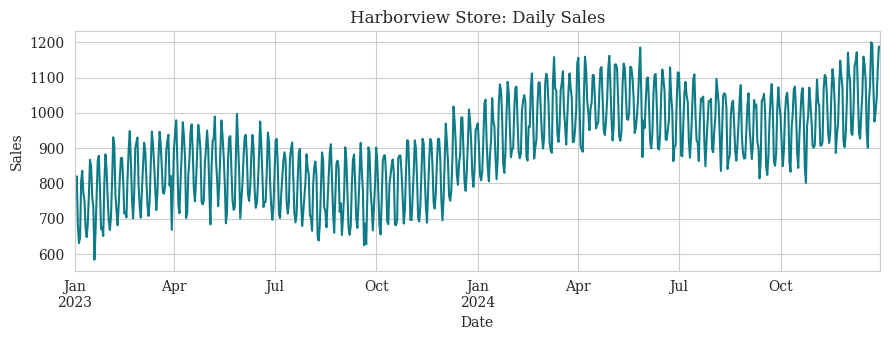

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sales = pd.read_excel("../data/synthetic_predictive_analytics_dataset.xlsx", sheet_name="Sales_Data", parse_dates=["date"])
store_series = sales[sales["store"] == "Harborview"].sort_values("date").set_index("date")["sales"]
print(store_series.shape)

store_series.plot(figsize=(9, 3.5), color="#0E7C86", title="Harborview Store: Daily Sales")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("../outputs/sales_history.png", dpi=120)
plt.show()

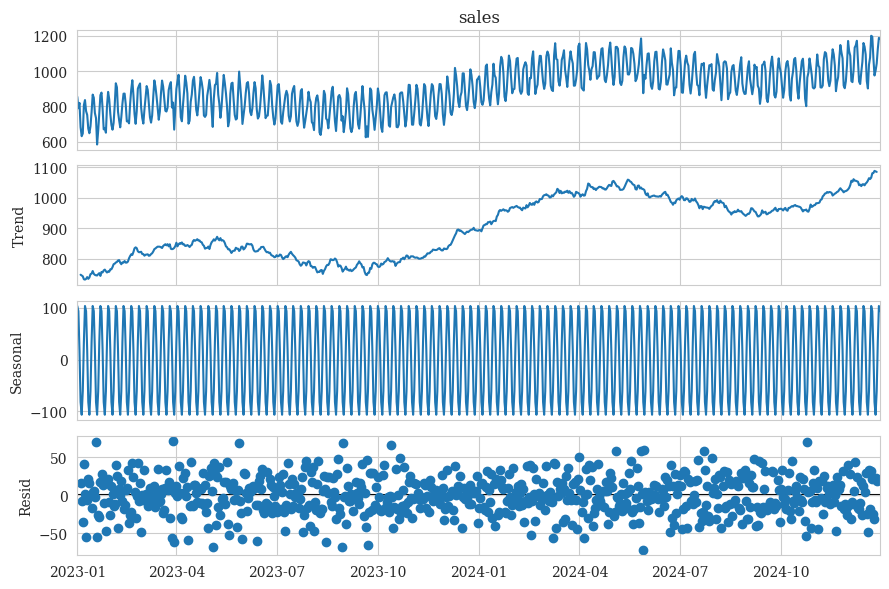

In [34]:
decomp = seasonal_decompose(store_series, model="additive", period=7)
fig = decomp.plot()
fig.set_size_inches(9, 6)
plt.tight_layout()
plt.savefig("../outputs/sales_seasonal_decomposition.png", dpi=120)
plt.show()

C:\Users\rubel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Holt-Winters RMSE on held-out 60 days: 59.3 units/day


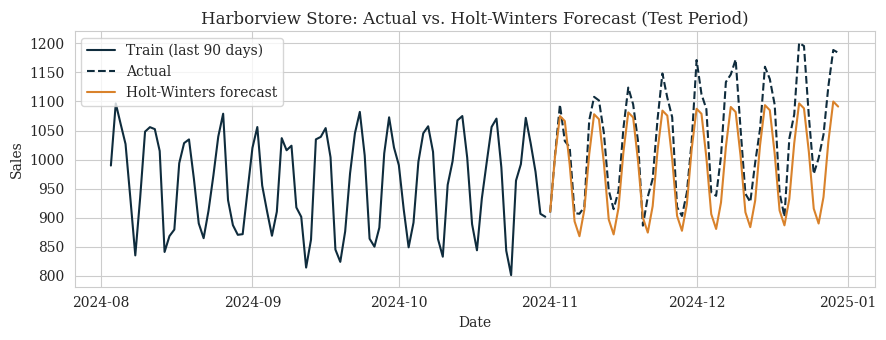

In [35]:
# Time-based split: last 60 days as the held-out test period
train, test = store_series[:-60], store_series[-60:]

hw_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7).fit()
forecast = hw_model.forecast(len(test))

hw_rmse = float(mean_squared_error(test, forecast) ** 0.5)
print(f"Holt-Winters RMSE on held-out 60 days: {hw_rmse:.1f} units/day")

plt.figure(figsize=(9, 3.5))
plt.plot(train[-90:], label="Train (last 90 days)", color="#0F2C3D")
plt.plot(test, label="Actual", color="#0F2C3D", linestyle="--")
plt.plot(test.index, forecast, label="Holt-Winters forecast", color="#D9822B")
plt.title("Harborview Store: Actual vs. Holt-Winters Forecast (Test Period)")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/sales_actual_vs_forecast.png", dpi=120)
plt.show()

The weekly cycle is obvious in this data — sales spike roughly every 7 days and dip in between, and Holt-Winters clearly picks up on that pattern, matching the timing of each peak and trough closely. Where it struggles is magnitude: as the test period goes on, actual peak sales keep climbing — reaching nearly 1200 by late December — while the forecasted peaks stay flat around 1080-1100. The troughs stay fairly accurate throughout, so the miss is specifically an underestimated upward trend, not the seasonality itself.

## Part 3 — Waiter Tips Prediction and Regression Refinement

We start from a plain baseline (bill amount only) and then add three refinements: the full
feature set with plain linear regression, a regularized (Ridge) version of the same features,
and a non-linear Random Forest. Comparing all four on the same held-out test set tells us
whether refining the model is actually worth it.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

tips = pd.read_excel("../data/synthetic_predictive_analytics_dataset.xlsx", sheet_name="Waiter_Tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,24.60,2.74,Female,Yes,Sat,Dinner,4
1,26.46,4.86,Male,Yes,Sat,Dinner,2
2,20.63,2.17,Male,Yes,Sat,Dinner,2
3,45.88,5.93,Female,No,Thur,Lunch,2
4,16.60,2.56,Female,Yes,Sat,Dinner,2


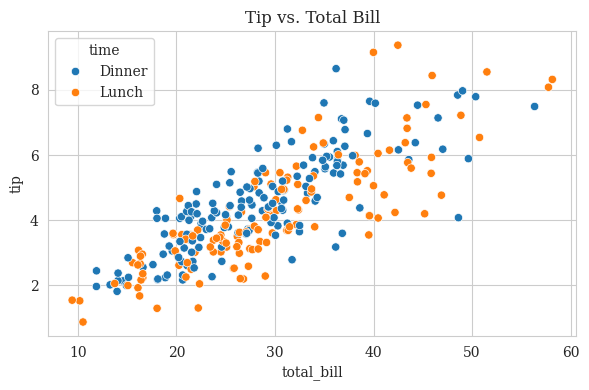

Correlation between total_bill and tip: 0.805


In [37]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.title("Tip vs. Total Bill")
plt.tight_layout()
plt.savefig("../outputs/tips_scatter.png", dpi=120)
plt.show()

print("Correlation between total_bill and tip:", round(tips["total_bill"].corr(tips["tip"]), 3))

In [38]:
X = tips.drop(columns="tip")
y = tips["tip"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = ["sex", "smoker", "day", "time"]
num_cols = ["total_bill", "size"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

model_metrics = {}

def evaluate(name, y_true, y_pred):
    r2 = float(r2_score(y_true, y_pred))
    rmse = float(mean_squared_error(y_true, y_pred) ** 0.5)
    model_metrics[name] = {"R2": r2, "RMSE": rmse}
    print(f"{name:35s} R2={r2:6.3f}   RMSE={rmse:.3f}")
    return r2, rmse

# --- Baseline: total_bill only, plain linear regression ---
baseline = LinearRegression()
baseline.fit(X_train[["total_bill"]], y_train)
baseline_pred = baseline.predict(X_test[["total_bill"]])
evaluate("Baseline (bill only)", y_test, baseline_pred)

Baseline (bill only)                R2= 0.552   RMSE=0.964


(0.551695862295237, 0.9642426577445761)

In [39]:
# --- Refinement 1: full feature set + linear regression, in a proper preprocessing pipeline ---
linreg_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])
linreg_pipe.fit(X_train, y_train)
linreg_pred = linreg_pipe.predict(X_test)
evaluate("Linear Regression (all features)", y_test, linreg_pred)

Linear Regression (all features)    R2= 0.621   RMSE=0.887


(0.6209582845910424, 0.8866321423738172)

In [40]:
# --- Refinement 2: Ridge regression (regularized) on the same features ---
ridge_pipe = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))])
ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)
evaluate("Ridge Regression", y_test, ridge_pred)

Ridge Regression                    R2= 0.622   RMSE=0.886


(0.6217615045898646, 0.8856922216195161)

In [41]:
# --- Refinement 3: Random Forest (non-linear) on the same features ---
rf_pipe = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(n_estimators=300, random_state=42))])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
evaluate("Random Forest", y_test, rf_pred)

Random Forest                       R2= 0.524   RMSE=0.994


(0.5239688409509653, 0.993613897681925)

In [42]:
comparison = pd.DataFrame(model_metrics).T.reset_index().rename(columns={"index": "Model"})
comparison = comparison.sort_values("R2", ascending=False).reset_index(drop=True)
comparison.to_csv("../outputs/tips_model_comparison.csv", index=False)
comparison

,Model,R2,RMSE
0,Ridge Regression,0.621762,0.885692
1,Linear Regression (all features),0.620958,0.886632
2,Baseline (bill only),0.551696,0.964243
3,Random Forest,0.523969,0.993614


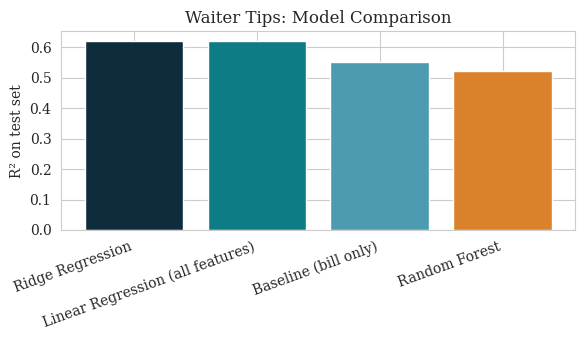

In [43]:
plt.figure(figsize=(6, 3.5))
plt.bar(comparison["Model"], comparison["R2"], color=["#0F2C3D", "#0E7C86", "#4C9BB0", "#D9822B"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("R² on test set")
plt.title("Waiter Tips: Model Comparison")
plt.tight_layout()
plt.savefig("../outputs/tips_model_comparison.png", dpi=120)
plt.show()

Linear Regression and Ridge both land around 0.62, a solid improvement over the baseline's 0.55 — so the extra features (day, time, party size, smoker status) genuinely help, not just noise. Ridge and Linear Regression score almost identically, suggesting the plain linear model wasn't overfitting much to begin with. Random Forest is the real surprise, scoring even lower than the baseline — with only a few hundred rows, it likely started fitting noise rather than signal, which points to the true relationship here being closer to linear than non-linear.

## Part 4 — Deploying a Prediction Pipeline

A trained model is only useful if it can be reused without retraining. We save the full
preprocessing-plus-model pipeline as a single file, then simulate a completely separate
process loading it back and predicting on brand-new inputs it has never seen.

In [44]:
import joblib

# NOTE: swap in whichever pipe you decide to deploy after writing your interpretation above.
best_pipe = rf_pipe
joblib.dump(best_pipe, "../outputs/tips_pipeline.joblib")
print("Pipeline saved to outputs/tips_pipeline.joblib")

# Simulate a completely separate process loading the saved pipeline
loaded_pipe = joblib.load("../outputs/tips_pipeline.joblib")

new_bills = pd.DataFrame([
    {"total_bill": 45.00, "sex": "Male", "smoker": "No", "day": "Sat", "time": "Dinner", "size": 4},
    {"total_bill": 18.50, "sex": "Female", "smoker": "Yes", "day": "Thur", "time": "Lunch", "size": 2},
])
predicted_tips = loaded_pipe.predict(new_bills)
for row, pred in zip(new_bills.to_dict("records"), predicted_tips):
    print(row, "-> predicted tip: $%.2f" % pred)

Pipeline saved to outputs/tips_pipeline.joblib
{'total_bill': 45.0, 'sex': 'Male', 'smoker': 'No', 'day': 'Sat', 'time': 'Dinner', 'size': 4} -> predicted tip: $7.13
{'total_bill': 18.5, 'sex': 'Female', 'smoker': 'Yes', 'day': 'Thur', 'time': 'Lunch', 'size': 2} -> predicted tip: $3.28


In a real deployment, this same `joblib.load(...)` -> `pipeline.predict(...)` pattern sits
behind a web API. A minimal example using FastAPI (illustrative only, not run in this notebook
since it needs a running server):

```python
# app.py -- a minimal prediction API (illustrative, not executed here)
from fastapi import FastAPI
import joblib, pandas as pd

app = FastAPI()
pipe = joblib.load("tips_pipeline.joblib")

@app.post("/predict")
def predict(total_bill: float, sex: str, smoker: str, day: str, time: str, size: int):
    row = pd.DataFrame([{
        "total_bill": total_bill, "sex": sex, "smoker": smoker,
        "day": day, "time": time, "size": size,
    }])
    return {"predicted_tip": float(pipe.predict(row)[0])}
```

## Save all metrics for the report


In [45]:
all_results = {
    "lstm_stock": {"ticker": "NOVATECH", "window": WINDOW, "RMSE": lstm_rmse},
    "holt_winters_sales": {"store": "Harborview", "test_days": 60, "RMSE": hw_rmse},
    "waiter_tips_models": model_metrics,
}
with open("../outputs/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print(json.dumps(all_results, indent=2))

{
  "lstm_stock": {
    "ticker": "NOVATECH",
    "window": 20,
    "RMSE": 2.848966898956716
  },
  "holt_winters_sales": {
    "store": "Harborview",
    "test_days": 60,
    "RMSE": 59.31595411442504
  },
  "waiter_tips_models": {
    "Baseline (bill only)": {
      "R2": 0.551695862295237,
      "RMSE": 0.9642426577445761
    },
    "Linear Regression (all features)": {
      "R2": 0.6209582845910424,
      "RMSE": 0.8866321423738172
    },
    "Ridge Regression": {
      "R2": 0.6217615045898646,
      "RMSE": 0.8856922216195161
    },
    "Random Forest": {
      "R2": 0.5239688409509653,
      "RMSE": 0.993613897681925
    }
  }
}
